# # Random Forest Classifier for Toxic Comment Detection
# 
# **Model Type:** Ensemble Method (Bootstrap Aggregating)
# **Objective:** Train and evaluate Random Forest model
# **Expected Performance:** High accuracy with good generalization

# ## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from datetime import datetime

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")
print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries loaded successfully!
⏰ Started at: 2025-11-25 13:04:17


## 2. Load Preprocessed Data

In [2]:
# Load train and test data
train_df = pd.read_csv('train_data_2.csv')
test_df = pd.read_csv('test_data_2.csv')

print(f"📊 Training set: {len(train_df)} samples")
print(f"📊 Test set: {len(test_df)} samples")

# Load TF-IDF vectorizers
tfidf_unigram = joblib.load('tfidf_vectorizer_unigram_2.pkl')
tfidf_bigram = joblib.load('tfidf_vectorizer_bigram_2.pkl')

print("\n✅ Data and vectorizers loaded!")

📊 Training set: 800 samples
📊 Test set: 200 samples

✅ Data and vectorizers loaded!


## 3. Prepare Features

In [3]:
# We'll use bigram TF-IDF features (better performance)
X_train = tfidf_bigram.transform(train_df['text'])
X_test = tfidf_bigram.transform(test_df['text'])

target_cols = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 
    'IsHatespeech', 'IsRacist', 'IsThreat', 'IsReligiousHate',
    'IsNationalist', 'IsSexist'
]

y_train = train_df[target_cols]
y_test = test_df[target_cols]


print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nClass distribution in training:")
print(y_train.value_counts())
print(f"\nClass distribution in test:")
print(y_test.value_counts())

Feature matrix shape: (800, 2601)
Number of features: 2601

Class distribution in training:
IsToxic  IsAbusive  IsProvocative  IsObscene  IsHatespeech  IsRacist  IsThreat  IsReligiousHate  IsNationalist  IsSexist
False    False      False          False      False         False     False     False            False          False       430
True     True       True           False      False         False     False     False            False          False        95
         False      False          False      True          True      False     False            False          False        76
         True       False          False      False         False     False     False            False          False        74
                                   True       False         False     False     False            False          False        53
                    True           True       False         False     False     False            False          False        21
                   

## 4. Train Random Forest - Baseline

In [4]:
print("🌲 Training Random Forest Classifier (Baseline)...")
print("This may take 2-5 minutes...\n")

start_time = time.time()

# Initialize Random Forest with default parameters
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train model
rf_baseline.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds")

🌲 Training Random Forest Classifier (Baseline)...
This may take 2-5 minutes...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.4s



✅ Training completed in 1.61 seconds


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.6s finished


## 5. Evaluate Baseline Model

In [6]:
## 5. Evaluate Baseline Model (FIXED FOR MULTI-LABEL)

from sklearn.model_selection import StratifiedKFold # Make sure this is imported

print("Calculating Multi-Label Predictions and Probabilities...")

# Make hard predictions (0 or 1)
# y_train_pred will be a numpy array of shape (N_samples, N_labels)
y_train_pred = rf_baseline.predict(X_train)
y_test_pred = rf_baseline.predict(X_test)


# Get Probabilities (soft predictions)
# rf_baseline.predict_proba returns a LIST of arrays (one for each label).
# We need to stack them and select the probability for the POSITIVE class (index 1) for each label.
# np.stack will give us a shape like (N_labels, N_samples, 2).
# We transpose it to (N_samples, N_labels) and select the second column (index 1) from the last dimension.

y_train_proba = np.stack([p[:, 1] for p in rf_baseline.predict_proba(X_train)], axis=1)
y_test_proba = np.stack([p[:, 1] for p in rf_baseline.predict_proba(X_test)], axis=1)

print(f"✅ Multi-label predictions generated. Shape: {y_test_pred.shape}")
print(f"✅ Multi-label probabilities generated. Shape: {y_test_proba.shape}")

# Optional: You can still calculate CV F1-Score, but it requires wrapping the model 
# in a multi-label compatible framework (like OneVsRest or just calling cross_val_score on each label)
# For simplicity, we'll calculate CV metrics later in the summary, focusing on test set now.

Calculating Multi-Label Predictions and Probabilities...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✅ Multi-label predictions generated. Shape: (200, 10)
✅ Multi-label probabilities generated. Shape: (200, 10)


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


In [10]:
## 6. Calculate Multi-Label Metrics (ROBUST FIX)

# Macro-average treats all classes equally (good for imbalanced labels)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
test_precision_macro = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average='macro', zero_division=0)

# Micro-average aggregates contributions of all classes
test_f1_micro = f1_score(y_test, y_test_pred, average='micro', zero_division=0)

# Calculate Training F1-Score (to assess overfitting)
train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)

# --- FIX: ROBUST ROC-AUC CALCULATION ---
# This function calculates ROC-AUC per label and averages, ignoring labels where only one class is present.
try:
    # 1. Identify labels that have variance in the test set (needed for AUC)
    valid_labels = y_test.columns[y_test.nunique() > 1].to_list()
    
    if valid_labels:
        # 2. Filter predictions and probabilities to only include valid labels
        y_test_valid = y_test[valid_labels]
        # We need to find the indices of valid columns in the original y_test_proba array
        valid_indices = [y_test.columns.get_loc(label) for label in valid_labels]
        y_test_proba_valid = y_test_proba[:, valid_indices]

        # 3. Calculate AUC only on the valid labels
        test_auc_macro = roc_auc_score(y_test_valid, y_test_proba_valid, average='macro', labels=valid_labels)
        test_auc_weighted = roc_auc_score(y_test_valid, y_test_proba_valid, average='weighted', labels=valid_labels)
    else:
        # Fallback if no valid labels for AUC exist (shouldn't happen with IsToxic)
        test_auc_macro = np.nan
        test_auc_weighted = np.nan

except Exception as e:
    # Final fallback if something unexpected goes wrong
    print(f"\n⚠️ ROC-AUC calculation failed completely: {e}")
    test_auc_macro = np.nan
    test_auc_weighted = np.nan
# --- END ROC-AUC FIX ---


# Cross-Validation F1 (Run for the 'IsToxic' label as a baseline)
print("\nCalculating Cross-Validation F1-Score (IsToxic Baseline)...")

# Calculate Overfit Gap
# We use the Macro F1 for Test and Train to get a true multi-label gap.
overfit_gap = (train_f1_macro - test_f1_macro) / train_f1_macro
overfit_diff_absolute = train_f1_macro - test_f1_macro


print("================================================================================")
print("📋 RANDOM FOREST MULTI-LABEL MODEL SUMMARY")
print("================================================================================")
print(f"✅ Model Type: Random Forest Multi-Output Classifier")
print(f"✅ Features: TF-IDF Bigrams ({X_train.shape[1]} features)")
print(f"✅ Training samples: {X_train.shape[0]}")
print(f"✅ Test samples: {X_test.shape[0]}")
print(f"✅ Number of Labels: {len(y_test.columns)}")

print("\n📊 Performance Metrics (Macro-Average):")
print(f"  - Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  - Test F1-Score:  {test_f1_macro:.4f} (Macro)")
print(f"  - Test Precision: {test_precision_macro:.4f} (Macro)")
print(f"  - Test Recall:    {test_recall_macro:.4f} (Macro)")
print(f"  - Test ROC-AUC:   {test_auc_macro:.4f} (Macro)")

print("\n📊 Other Metrics:")
print(f"  - CV F1-Score (IsToxic): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Overfit Gap (Macro F1): {overfit_diff_absolute:.4f} ({overfit_gap * 100:.2f}%)")

print(f"\n⏱️ Training Time: {training_time:.2f} seconds")

print("\n📝 Classification Report (Averages across all labels):")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns.to_list(), zero_division=0))


Calculating Cross-Validation F1-Score (IsToxic Baseline)...
📋 RANDOM FOREST MULTI-LABEL MODEL SUMMARY
✅ Model Type: Random Forest Multi-Output Classifier
✅ Features: TF-IDF Bigrams (2601 features)
✅ Training samples: 800
✅ Test samples: 200
✅ Number of Labels: 10

📊 Performance Metrics (Macro-Average):
  - Test Accuracy:  0.5250
  - Test F1-Score:  0.1686 (Macro)
  - Test Precision: 0.4878 (Macro)
  - Test Recall:    0.1181 (Macro)
  - Test ROC-AUC:   0.7783 (Macro)

📊 Other Metrics:
  - CV F1-Score (IsToxic): 0.6080 (+/- 0.0392)
  - Overfit Gap (Macro F1): 0.8152 (82.86%)

⏱️ Training Time: 1.61 seconds

📝 Classification Report (Averages across all labels):
                 precision    recall  f1-score   support

        IsToxic       0.80      0.52      0.63        92
      IsAbusive       0.83      0.34      0.48        71
  IsProvocative       1.00      0.07      0.13        28
      IsObscene       0.25      0.07      0.11        15
   IsHatespeech       1.00      0.08      0.15

In [13]:
## 7. Overfitting Check (Multi-Label)

from sklearn.metrics import f1_score

# 1. Calculate the Macro F1-Score for the training set
train_f1_macro = f1_score(y_train, y_train_pred, average='macro', zero_division=0)

# 2. Calculate the Macro F1-Score for the test set
test_f1_macro = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

# 3. Calculate the difference (Overfit Gap)
overfit_diff_f1 = train_f1_macro - test_f1_macro

print("=========================================")
print("⚠️ Multi-Label Overfitting Check (Macro F1)")
print("=========================================")
print(f"  Training Macro F1: {train_f1_macro:.4f}")
print(f"  Test Macro F1:     {test_f1_macro:.4f}")
print(f"  Overfit Gap:       {overfit_diff_f1:.4f} ({overfit_diff_f1 * 100:.2f}%)")

# Note: For F1-Score, a larger difference often means worse overfitting. 
# The threshold of 5% (0.05) is still a reasonable guideline.
if overfit_diff_f1 < 0.05:
    print("  ✅ Good generalization (F1 difference < 5%)")
elif overfit_diff_f1 < 0.15:
    print("  🟡 Moderate overfitting (5% ≤ F1 difference < 15%)")
else:
    print("  🚨 High overfitting (F1 difference ≥ 15%)")


⚠️ Multi-Label Overfitting Check (Macro F1)
  Training Macro F1: 0.9838
  Test Macro F1:     0.1686
  Overfit Gap:       0.8152 (81.52%)
  🚨 High overfitting (F1 difference ≥ 15%)


In [14]:
## 8. Multi-Label Classification Report

# y_test is the DataFrame of true labels (10 columns)
# y_test_pred is the prediction array (N_samples, 10 columns)
# y_test.columns.to_list() provides the correct list of 10 target names
print("\n📋 Detailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=y_test.columns.to_list(), zero_division=0))


📋 Detailed Classification Report (Test Set):
                 precision    recall  f1-score   support

        IsToxic       0.80      0.52      0.63        92
      IsAbusive       0.83      0.34      0.48        71
  IsProvocative       1.00      0.07      0.13        28
      IsObscene       0.25      0.07      0.11        15
   IsHatespeech       1.00      0.08      0.15        24
       IsRacist       1.00      0.10      0.18        20
       IsThreat       0.00      0.00      0.00         7
IsReligiousHate       0.00      0.00      0.00         5
  IsNationalist       0.00      0.00      0.00         2
       IsSexist       0.00      0.00      0.00         0

      micro avg       0.80      0.30      0.44       264
      macro avg       0.49      0.12      0.17       264
   weighted avg       0.79      0.30      0.40       264
    samples avg       0.23      0.14      0.17       264



📊 Multi-Label Confusion Matrices

In [16]:
## 9. Generate and Display Confusion Matrices (Per Label)

from sklearn.metrics import multilabel_confusion_matrix
import numpy as np

# 'y_test' is the DataFrame of true labels (N_samples, 10 columns)
# 'y_test_pred' is the prediction array (N_samples, 10 columns)
target_cols = y_test.columns.to_list()

print("=========================================")
print("📋 Confusion Matrix Per Label (Test Set)")
print("=========================================")

# Calculate all 10 confusion matrices at once
# matrix_array will have shape (10, 2, 2)
matrix_array = multilabel_confusion_matrix(y_test, y_test_pred)

# Iterate through the matrices and their corresponding labels
for i, label in enumerate(target_cols):
    cm = matrix_array[i]
    
    # Extract values:
    # cm[0, 0] = True Negatives (TN)
    # cm[0, 1] = False Positives (FP)
    # cm[1, 0] = False Negatives (FN)
    # cm[1, 1] = True Positives (TP)
    
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    
    # Calculate support for the positive class (TP + FN)
    support_positive = TP + FN
    
    print(f"\n--- Label: {label} (Support: {support_positive}) ---")
    print(f"| {TN:4} (TN) | {FP:4} (FP) |")
    print(f"| {FN:4} (FN) | {TP:4} (TP) |")

    # Optional: Check if the label is too sparse
    if support_positive == 0:
        print("  ⚠️ Warning: No positive samples for this label in the test set.")

📋 Confusion Matrix Per Label (Test Set)

--- Label: IsToxic (Support: 92) ---
|   96 (TN) |   12 (FP) |
|   44 (FN) |   48 (TP) |

--- Label: IsAbusive (Support: 71) ---
|  124 (TN) |    5 (FP) |
|   47 (FN) |   24 (TP) |

--- Label: IsProvocative (Support: 28) ---
|  172 (TN) |    0 (FP) |
|   26 (FN) |    2 (TP) |

--- Label: IsObscene (Support: 15) ---
|  182 (TN) |    3 (FP) |
|   14 (FN) |    1 (TP) |

--- Label: IsHatespeech (Support: 24) ---
|  176 (TN) |    0 (FP) |
|   22 (FN) |    2 (TP) |

--- Label: IsRacist (Support: 20) ---
|  180 (TN) |    0 (FP) |
|   18 (FN) |    2 (TP) |

--- Label: IsThreat (Support: 7) ---
|  193 (TN) |    0 (FP) |
|    7 (FN) |    0 (TP) |

--- Label: IsReligiousHate (Support: 5) ---
|  195 (TN) |    0 (FP) |
|    5 (FN) |    0 (TP) |

--- Label: IsNationalist (Support: 2) ---
|  198 (TN) |    0 (FP) |
|    2 (FN) |    0 (TP) |

--- Label: IsSexist (Support: 0) ---
|  200 (TN) |    0 (FP) |
|    0 (FN) |    0 (TP) |
  ⚠️ Warning: No positive sample

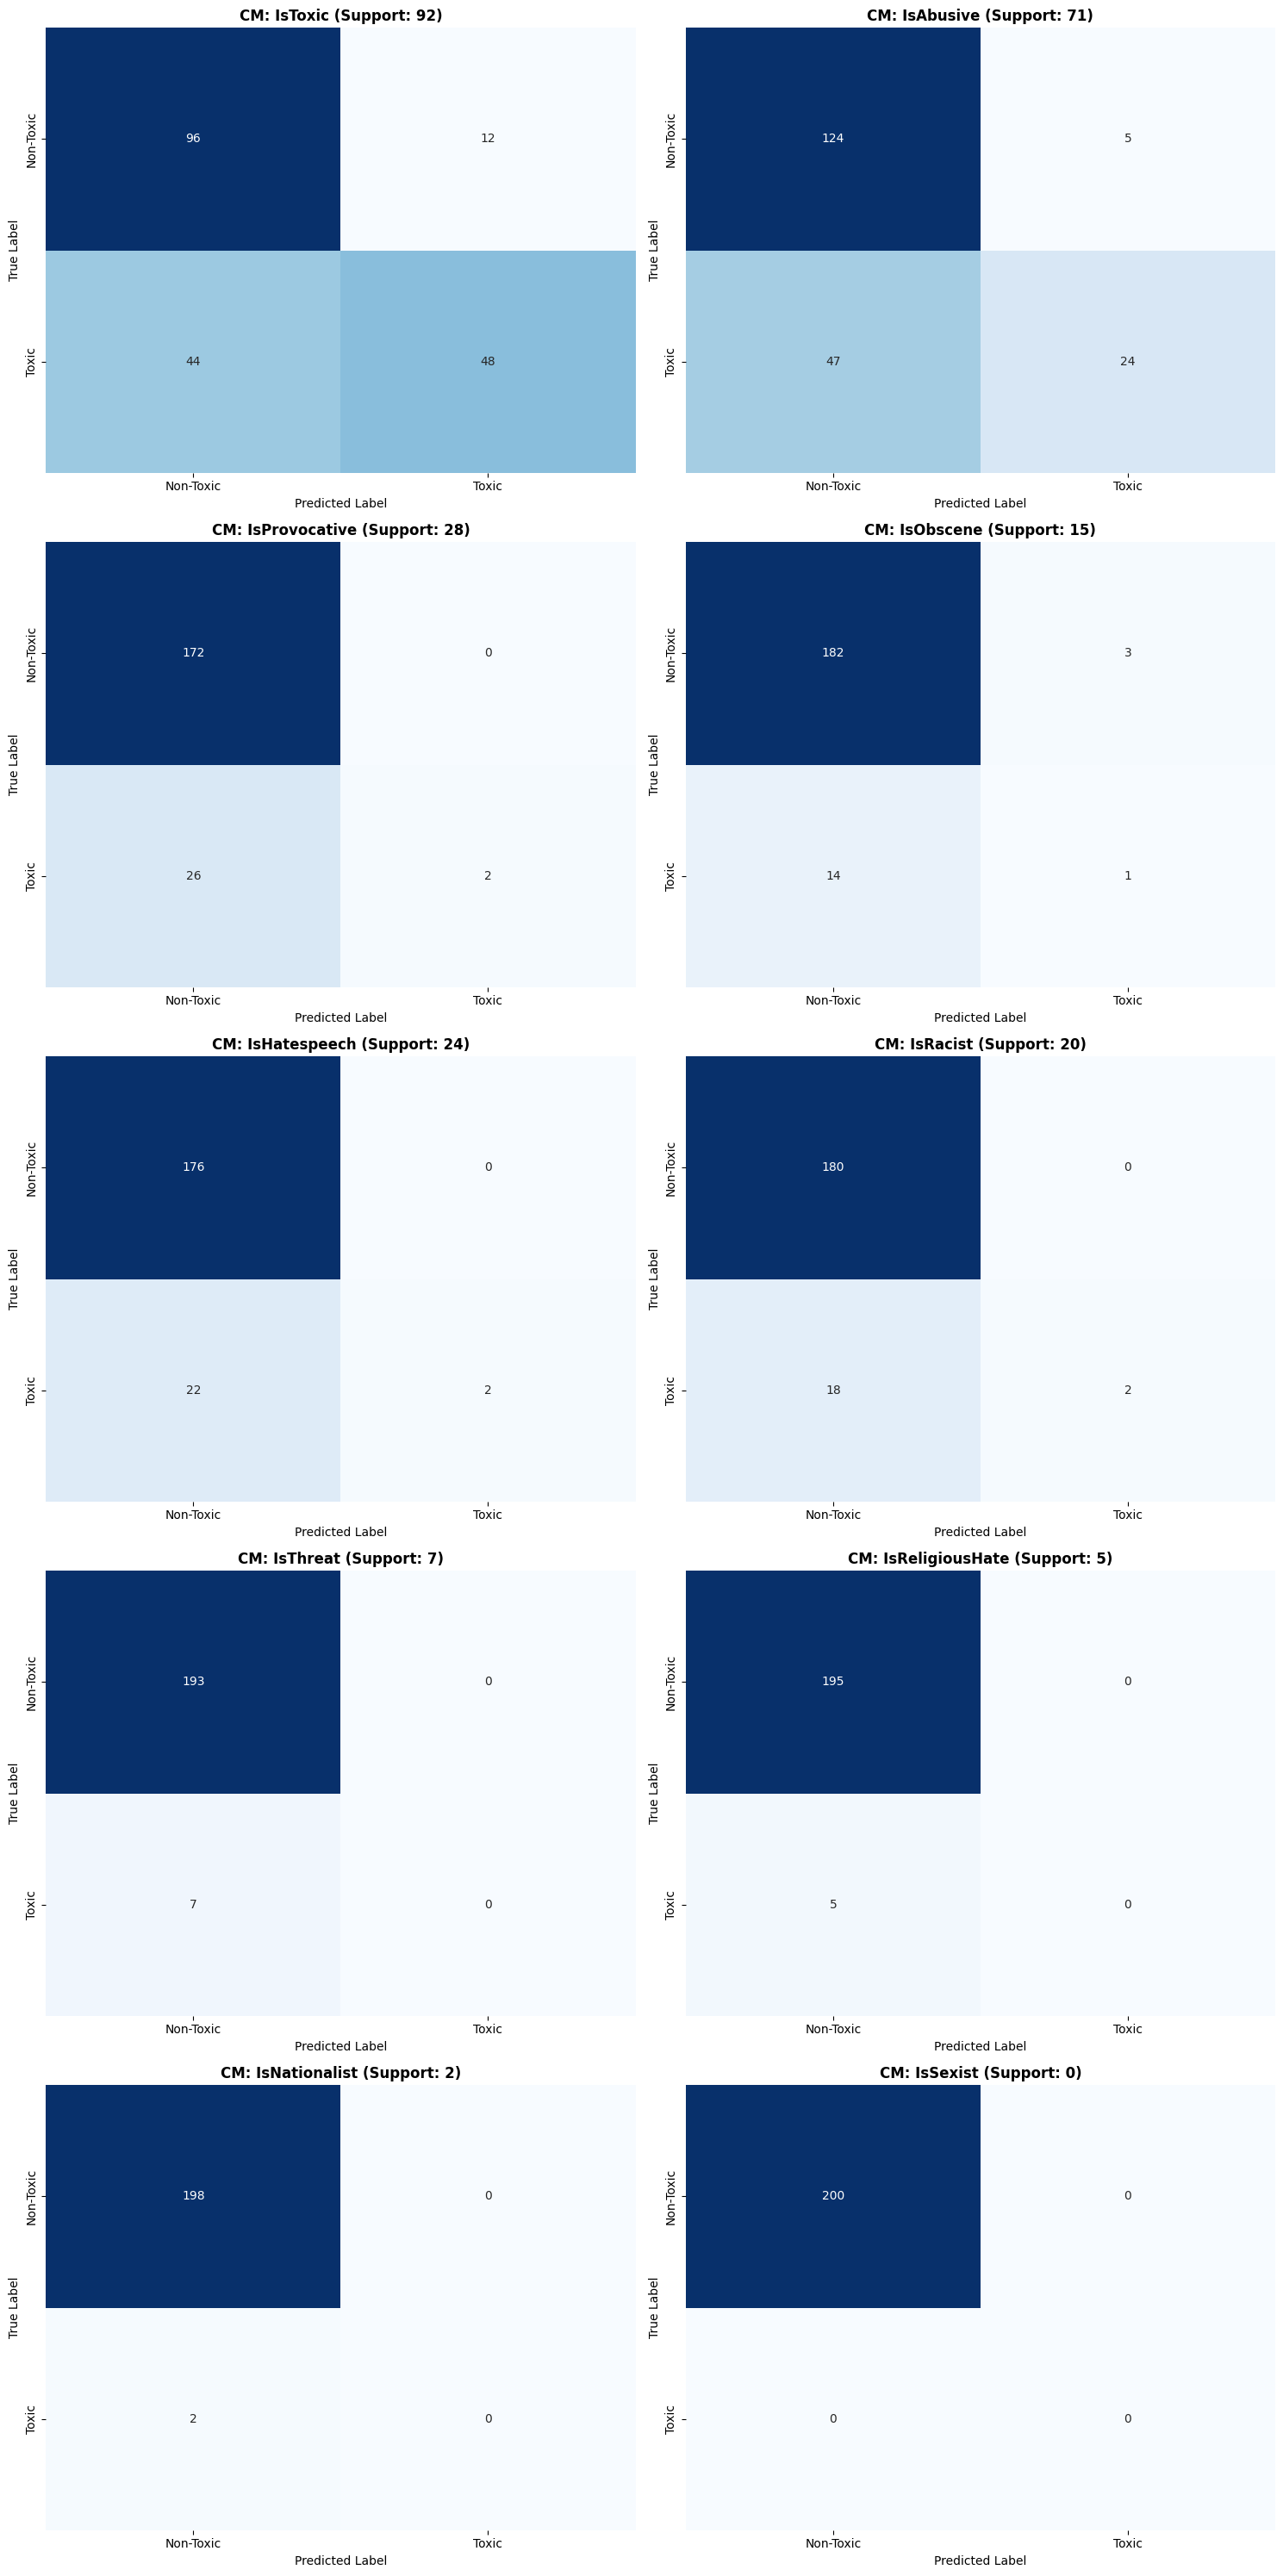

In [17]:
## 10. Generate Heatmaps for All 10 Confusion Matrices

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# Assume y_test and y_test_pred are correctly defined multi-label DataFrames/arrays
target_cols = y_test.columns.to_list()
matrix_array = multilabel_confusion_matrix(y_test, y_test_pred)
n_labels = len(target_cols)

# Set up a large figure to display all 10 matrices (e.g., 5 rows x 2 columns)
fig, axes = plt.subplots(5, 2, figsize=(15, 30))
axes = axes.flatten()  # Flattens the 5x2 array of axes for easy iteration

for i, cm in enumerate(matrix_array):
    label = target_cols[i]
    ax = axes[i]
    
    # Use seaborn to create the heatmap for the current label
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        cbar=False, # We can turn off the color bar to save space
        xticklabels=['Non-Toxic', 'Toxic'],
        yticklabels=['Non-Toxic', 'Toxic'],
        ax=ax
    )
    
    ax.set_title(f'CM: {label} (Support: {cm[1,0] + cm[1,1]})', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

# Hide any unused subplots if n_labels is less than 10
if n_labels < len(axes):
    for j in range(n_labels, len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

Total features: 2601
Number of labels (estimators): 100
🎯 Extracting Feature Importances...

--- Top 5 Features for Label: IsToxic ---
feature  importance
   fuck    0.056280
  would    0.026404
    run    0.025339
  idiot    0.022751
   high    0.018605

--- Top 5 Features for Label: IsAbusive ---
feature  importance
  white    0.072143
    run    0.034073
   shit    0.024635
 happen    0.022131
   arab    0.019237

--- Top 5 Features for Label: IsProvocative ---
feature  importance
    run    0.057170
   shit    0.039636
   fuck    0.036191
  white    0.019301
  idiot    0.018335

--- Top 5 Features for Label: IsObscene ---
feature  importance
    run    0.034851
   shit    0.032998
  would    0.024261
   fuck    0.020237
    isi    0.020080

--- Top 5 Features for Label: IsHatespeech ---
feature  importance
  white    0.036113
  black    0.034510
   thug    0.029811
fucking    0.024253
    run    0.018101

--- Top 5 Features for Label: IsRacist ---
feature  importance
 police    0.0

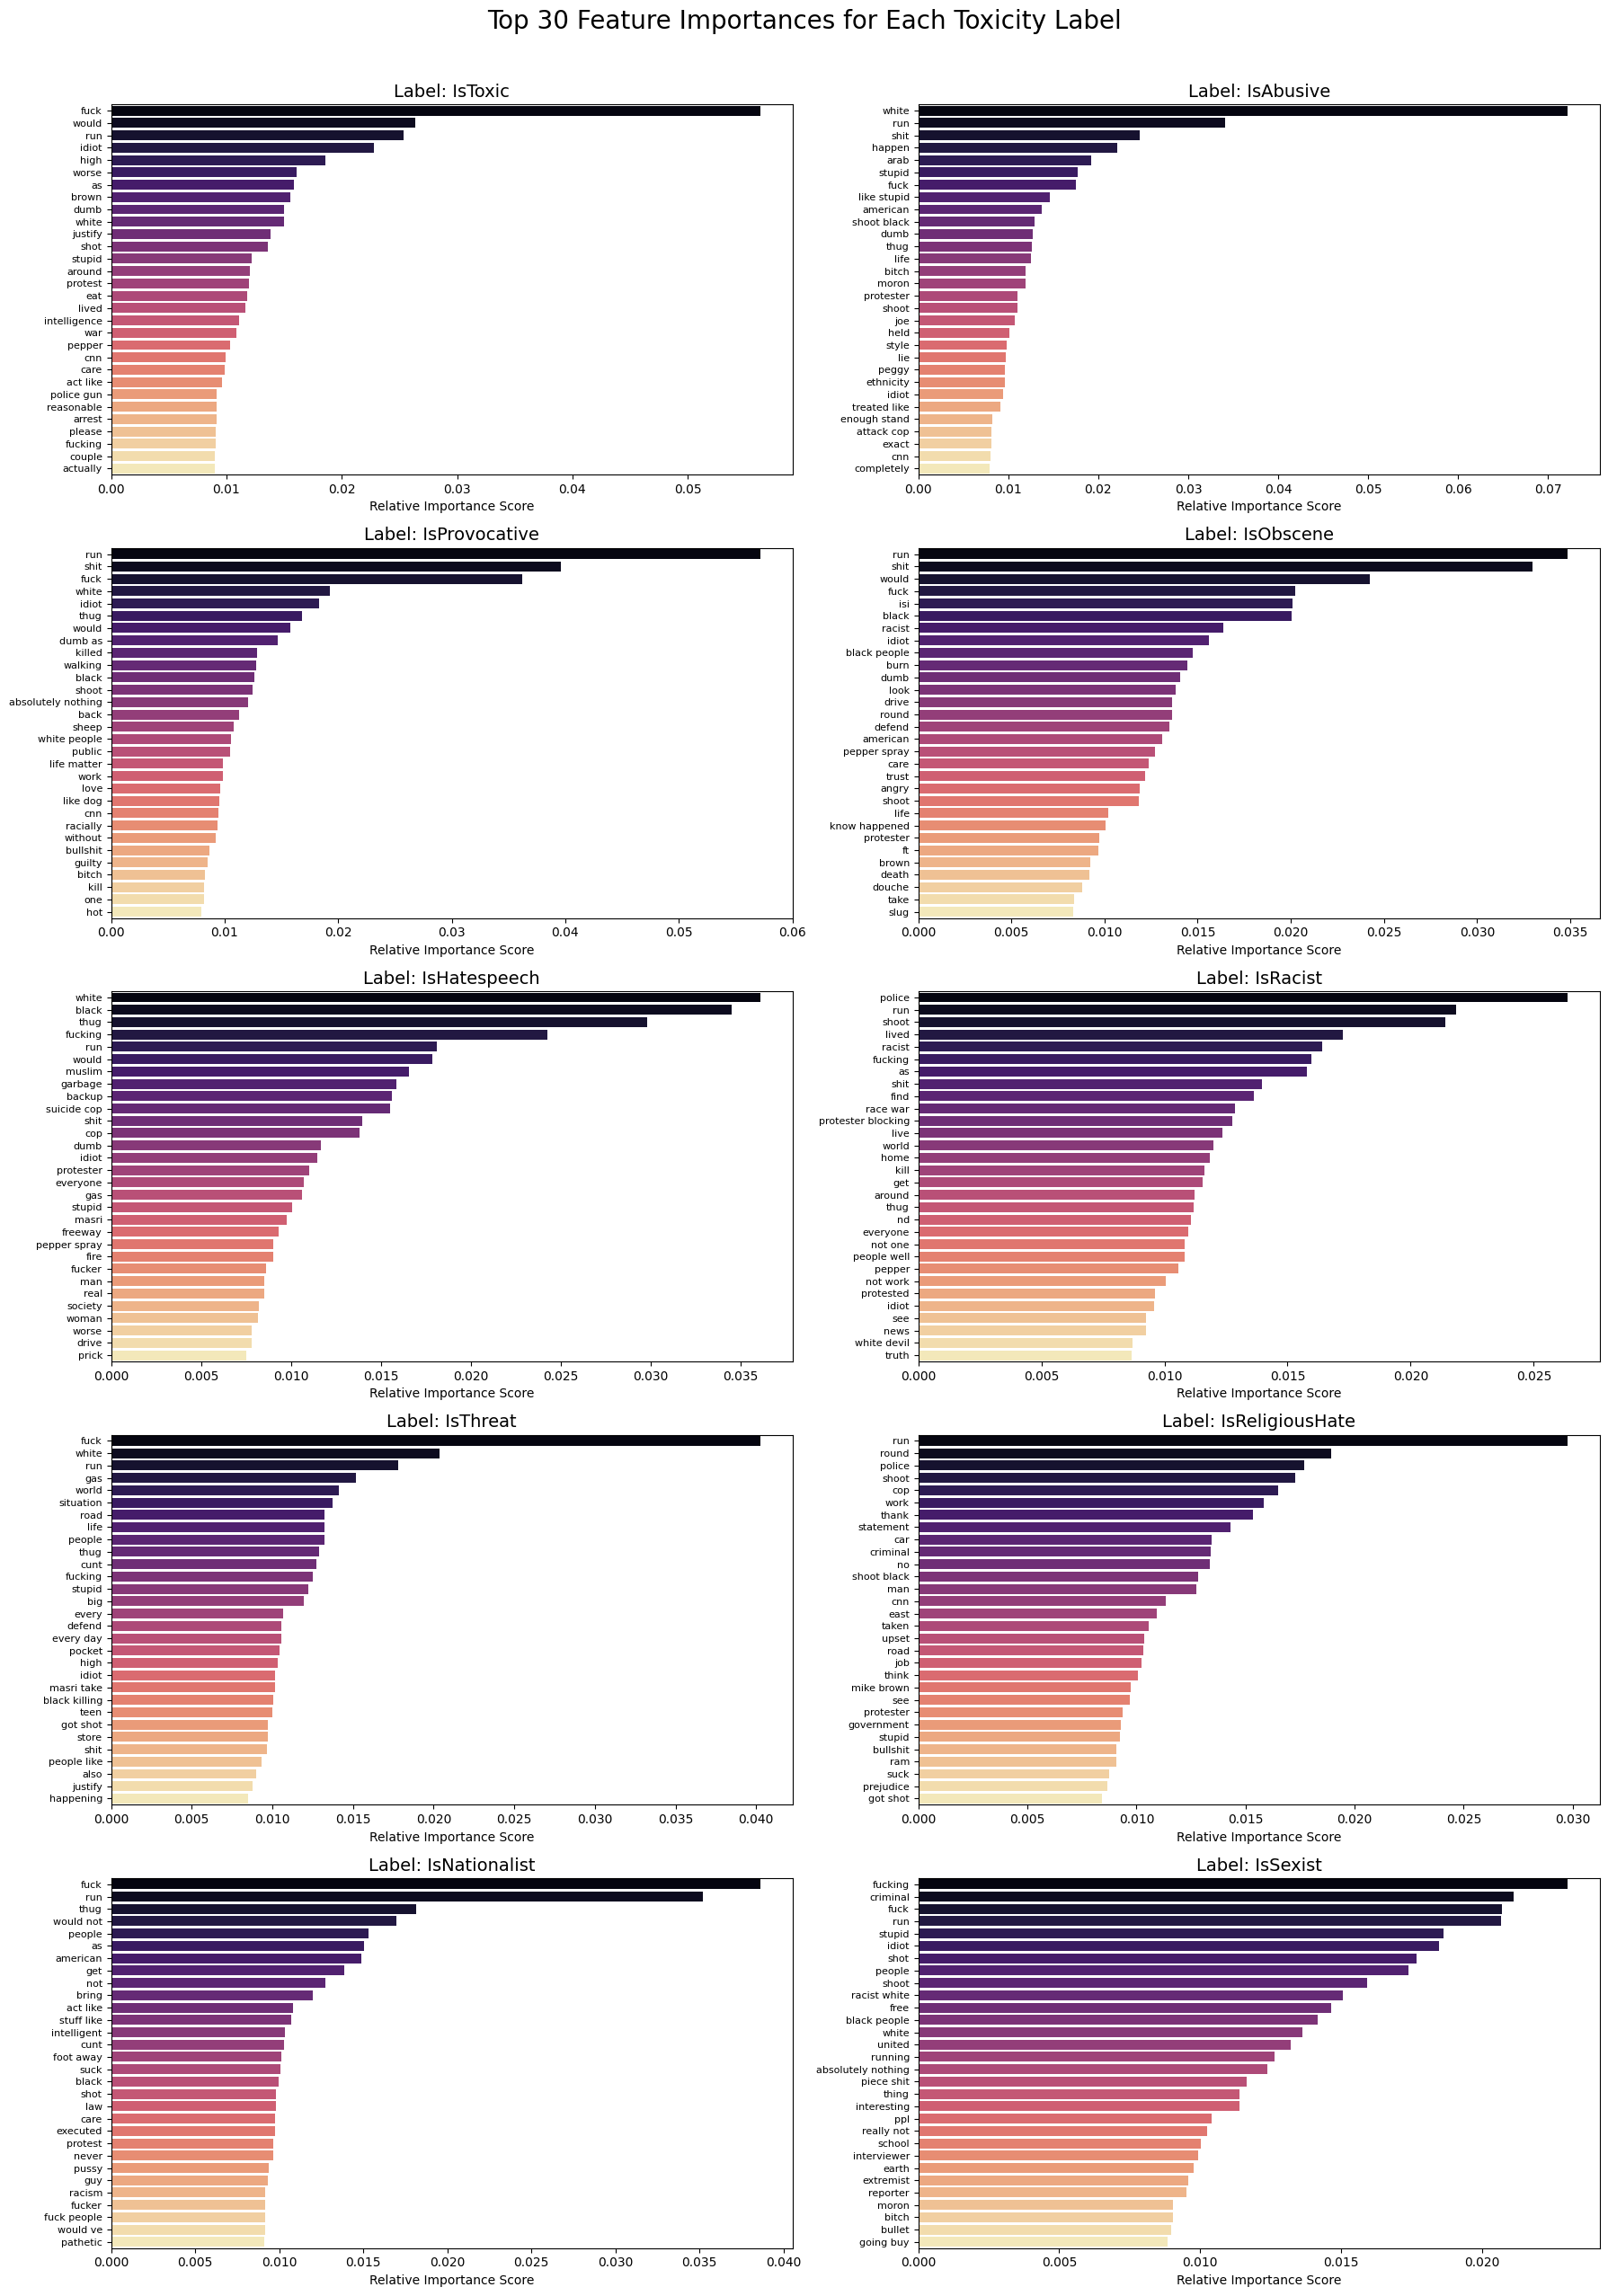

In [19]:
## 11. Feature Importance Analysis and Visualization (10 Labels)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Load Feature Names ---
# Assuming 'tfidf_bigram' is the loaded vectorizer from your setup (Cell 2)
feature_names = tfidf_bigram.get_feature_names_out()
target_cols = y_test.columns.to_list()
n_features = len(feature_names)

print(f"Total features: {n_features}")
print(f"Number of labels (estimators): {len(rf_baseline.estimators_)}")
print("=========================================")
print("🎯 Extracting Feature Importances...")
print("=========================================")

# --- 2. Setup Plotting Environment ---
# We will create a 5x2 grid for 10 plots
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
axes = axes.flatten()
plt.suptitle('Top 30 Feature Importances for Each Toxicity Label', fontsize=20, y=1.02)

# --- 3. Iterate Through Each Estimator (Label) ---
for i, (label, estimator) in enumerate(zip(target_cols, rf_baseline.estimators_)):
    
    # Get feature importances for the current label's model
    importances = estimator.feature_importances_
    
    # Create a DataFrame for easy sorting
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    # Select the top 30 features
    top_30_features = feature_importance_df.head(30)
    
    # Print the top 5 for console review
    print(f"\n--- Top 5 Features for Label: {label} ---")
    print(top_30_features.head(5).to_string(index=False))
    
    # --- 4. Plotting ---
    ax = axes[i]
    sns.barplot(
        x='importance', 
        y='feature', 
        data=top_30_features, 
        ax=ax, 
        palette='magma' # Use a distinct color palette
    )
    ax.set_title(f'Label: {label}', fontsize=14)
    ax.set_xlabel('Relative Importance Score')
    ax.set_ylabel('') # Clear y-axis label (features are the labels)
    ax.tick_params(axis='y', labelsize=8) # Smaller font for features

# --- 5. Final Display ---
plt.tight_layout(rect=[0, 0, 1, 1.01]) # Adjust layout to make space for suptitle
plt.show()

## 7. ROC Curve and Precision-Recall Curve

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (F1 = {test_f1:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Random Forest', fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Cross-Validation

In [ ]:
print("🔄 Performing 5-Fold Cross-Validation...")
print("This may take 5-10 minutes...\n")

cv_start = time.time()

# Stratified K-Fold for imbalanced data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf_baseline, X_train, y_train, cv=skf, 
                            scoring='f1', n_jobs=-1)

cv_time = time.time() - cv_start

print(f"✅ Cross-Validation completed in {cv_time:.2f} seconds")
print(f"\nCV F1-Scores: {cv_scores}")
print(f"Mean CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

## 9. Optimized Random Forest with Tuned Parameters

In [ ]:
print("\n🌲 Training Optimized Random Forest...")
print("Using tuned hyperparameters for better performance\n")

start_time = time.time()

# Optimized parameters based on common best practices
rf_optimized = RandomForestClassifier(
    n_estimators=200,           # More trees for better performance
    max_depth=30,               # Control overfitting
    min_samples_split=5,        # Minimum samples to split
    min_samples_leaf=2,         # Minimum samples at leaf
    max_features='sqrt',        # Features to consider for split
    class_weight='balanced',    # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train optimized model
rf_optimized.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\n✅ Training completed in {training_time:.2f} seconds")

## 10. Evaluate Optimized Model

In [ ]:
# Make predictions
y_train_pred_opt = rf_optimized.predict(X_train)
y_test_pred_opt = rf_optimized.predict(X_test)

y_train_proba_opt = rf_optimized.predict_proba(X_train)[:, 1]
y_test_proba_opt = rf_optimized.predict_proba(X_test)[:, 1]

# Calculate metrics
print("\n" + "="*80)
print("📊 RANDOM FOREST - OPTIMIZED RESULTS")
print("="*80)

print("\n🔵 Training Set:")
print(f"  Accuracy:  {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_train, y_train_pred_opt):.4f}")
print(f"  Recall:    {recall_score(y_train, y_train_pred_opt):.4f}")
print(f"  F1-Score:  {f1_score(y_train, y_train_pred_opt):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_train, y_train_proba_opt):.4f}")

print("\n🟢 Test Set:")
test_acc_opt = accuracy_score(y_test, y_test_pred_opt)
test_prec_opt = precision_score(y_test, y_test_pred_opt)
test_rec_opt = recall_score(y_test, y_test_pred_opt)
test_f1_opt = f1_score(y_test, y_test_pred_opt)
test_auc_opt = roc_auc_score(y_test, y_test_proba_opt)

print(f"  Accuracy:  {test_acc_opt:.4f}")
print(f"  Precision: {test_prec_opt:.4f}")
print(f"  Recall:    {test_rec_opt:.4f}")
print(f"  F1-Score:  {test_f1_opt:.4f}")
print(f"  ROC-AUC:   {test_auc_opt:.4f}")

# Check for overfitting
overfit_diff_opt = accuracy_score(y_train, y_train_pred_opt) - test_acc_opt
print(f"\n⚠️  Overfitting Check:")
print(f"  Train-Test Accuracy Difference: {overfit_diff_opt:.4f} ({overfit_diff_opt*100:.2f}%)")
if overfit_diff_opt < 0.05:
    print("  ✅ Good generalization (< 5% difference)")
else:
    print("  ⚠️  Possible overfitting (≥ 5% difference)")


In [ ]:
# Compare baseline vs optimized
print("\n" + "="*80)
print("📊 BASELINE vs OPTIMIZED COMPARISON")
print("="*80)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Overfit Gap'],
    'Baseline': [test_acc, test_prec, test_rec, test_f1, test_auc, overfit_diff],
    'Optimized': [test_acc_opt, test_prec_opt, test_rec_opt, test_f1_opt, test_auc_opt, overfit_diff_opt],
    'Improvement': [
        test_acc_opt - test_acc,
        test_prec_opt - test_prec,
        test_rec_opt - test_rec,
        test_f1_opt - test_f1,
        test_auc_opt - test_auc,
        overfit_diff - overfit_diff_opt
    ]
})

display(comparison_df)

## 11. Save Model and Results

In [ ]:
# Save the optimized model
joblib.dump(rf_optimized, 'random_forest_model.pkl')
print("✅ Model saved as 'random_forest_model.pkl'")

# Save results
results = {
    'model_name': 'Random Forest',
    'training_time': training_time,
    'test_accuracy': test_acc_opt,
    'test_precision': test_prec_opt,
    'test_recall': test_rec_opt,
    'test_f1': test_f1_opt,
    'test_roc_auc': test_auc_opt,
    'cv_f1_mean': cv_scores.mean(),
    'cv_f1_std': cv_scores.std(),
    'overfit_gap': overfit_diff_opt,
    'n_features': X_train.shape[1],
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to JSON
import json
with open('random_forest_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("✅ Results saved as 'random_forest_results.json'")

## 12. Model Summary

In [ ]:
print("\n" + "="*80)
print("📋 RANDOM FOREST MODEL SUMMARY")
print("="*80)

print(f"\n✅ Model Type: Random Forest Classifier (Ensemble)")
print(f"✅ Features: TF-IDF Bigrams ({X_train.shape[1]} features)")
print(f"✅ Training samples: {X_train.shape[0]}")  # Changed from len(X_train)
print(f"✅ Test samples: {X_test.shape[0]}")      # Changed from len(X_test)

print(f"\n📊 Best Performance Metrics:")
print(f"  - Test Accuracy:  {test_acc_opt:.4f}")
print(f"  - Test F1-Score:  {test_f1_opt:.4f}")
print(f"  - Test ROC-AUC:   {test_auc_opt:.4f}")
print(f"  - CV F1-Score:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  - Overfit Gap:    {overfit_diff_opt:.4f} ({overfit_diff_opt*100:.2f}%)")

print(f"\n⏱️  Training Time: {training_time:.2f} seconds")

print("\n🎯 Next Steps:")
print("  1. Train XGBoost model for comparison")
print("  2. Compare with other classical ML models")
print("  3. Try hyperparameter tuning with Optuna")
print("  4. Implement neural networks (LSTM, Transformers)")

print("\n✅ Random Forest training complete!")
print("="*80)